# MediaPipe Head Movement Parity Test

"
"This notebook reproduces the `owf.head_movement()` output surface on `video.mov` using MediaPipe-derived face geometry instead of `py-feat/img2pose`.

"
"Implemented pose backends:
"
"- `matrix`: MediaPipe Face Landmarker transformation matrix -> rotation matrix -> Euler angles
"
"- `pnp`: MediaPipe face landmarks -> OpenCV `solvePnP` -> rotation matrix -> Euler angles

"
"For each backend, the notebook builds two variants:
"
"- `raw`: direct pose output from the backend
"
"- `calibrated_smoothed`: pose relative to a neutral baseline with EMA smoothing

"
"The notebook also runs `owf.head_movement(...)` on the same video, compares schema-level parity and metric deltas, and reports runtime benchmarks.


## 1. Goal, assumptions, and config

"
"Assumptions locked for this parity artifact:
"
"- Target behavior is the `bbox_list=[]` path of `owf.head_movement()`.
"
"- Output schema and metric semantics match `owf.head_movement()`, but numeric equality with `py-feat/img2pose` is not expected.
"
"- `padding_percent` is accepted for config parity, but unused in the MediaPipe path because this notebook derives face boxes directly from landmarks.
"
"- `matrix` and `pnp` share one MediaPipe extraction pass so the comparison isolates pose estimation differences instead of detector differences.


In [1]:
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "openwillis-face").exists() and (ROOT.parent / "openwillis-face").exists():
    ROOT = ROOT.parent

NOTEBOOK_DIR = ROOT / "head_movement"
MODEL_DIR = NOTEBOOK_DIR / "models"
MODEL_PATH = MODEL_DIR / "face_landmarker.task"

CONFIG = {
    "video_path": ROOT / "video.mov",
    "frames_per_second": 30,
    "normalize_by_bb_size": False,
    "bbox_list": [],
    "padding_percent": 0.1,
    "ema_alpha": 0.3,
    "neutral_window_seconds": 1.0,
    "model_url": "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task",
    "model_path": MODEL_PATH,
}

assert CONFIG["video_path"].exists(), f"Missing video: {CONFIG['video_path']}"
assert CONFIG["bbox_list"] == [], "This notebook targets the bbox_list=[] path only."
CONFIG


{'video_path': PosixPath('/Users/pelmeshek1706/Desktop/projects/airest-face/video.mov'),
 'frames_per_second': 30,
 'normalize_by_bb_size': False,
 'bbox_list': [],
 'padding_percent': 0.1,
 'ema_alpha': 0.3,
 'neutral_window_seconds': 1.0,
 'model_url': 'https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task',
 'model_path': PosixPath('/Users/pelmeshek1706/Desktop/projects/airest-face/head_movement/models/face_landmarker.task')}

## 2. Imports and display helpers

In [2]:
import math
import sys
import time
import urllib.request
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import cv2
import matplotlib.pyplot as plt
import mediapipe as mp
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

OPENWILLIS_SRC = ROOT / "openwillis-face" / "src"
if str(OPENWILLIS_SRC) not in sys.path:
    sys.path.insert(0, str(OPENWILLIS_SRC))

import openwillis.face as owf

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
plt.rcParams["figure.figsize"] = (14, 4)
plt.rcParams["axes.grid"] = True


## 3. Reference implementation summary from `head_movement.py`

"
"The reference function in `openwillis-face/src/openwillis/face/head_movement.py` does the following:
"
"1. Samples frames using `skip_interval = max(1, int(video_fps / frames_per_second))`.
"
"2. Writes a full-length output with `NaN` rows for unsampled or failed frames.
"
"3. Produces pose columns in the order `[pitch, roll, yaw]`.
"
"4. Computes bbox centers, frame-to-frame `xy_disp`, aggregate `euclidean_angle`, and `euclidean_angle_disp`.
"
"5. Returns a framewise DataFrame plus a one-row summary DataFrame with mean/std aggregations.

"
"The helper block below reimplements only the minimal metric semantics needed to keep MediaPipe outputs aligned with that contract.


## 4. Shared math helpers

In [3]:
FRAMEWISE_COLUMNS = [
    "frame",
    "bb_x1",
    "bb_y1",
    "bb_x2",
    "bb_y2",
    "face_confidence",
    "pitch",
    "roll",
    "yaw",
    "time",
    "bb_center_x",
    "bb_center_y",
    "euclidean_angle",
    "euclidean_angle_disp",
    "xy_disp",
]

SUMMARY_COLUMNS = [
    "xy_disp_mean",
    "pitch_mean",
    "yaw_mean",
    "roll_mean",
    "euclidean_angle_disp_mean",
    "xy_disp_std",
    "pitch_std",
    "yaw_std",
    "roll_std",
    "euclidean_angle_disp_std",
]

PNP_LANDMARK_IDS = {
    "nose_tip": 1,
    "chin": 152,
    "left_eye_outer": 33,
    "right_eye_outer": 263,
    "left_mouth": 61,
    "right_mouth": 291,
}

GENERIC_FACE_MODEL_POINTS = np.array([
    [0.0, 0.0, 0.0],
    [0.0, -63.6, -12.5],
    [-43.3, 32.7, -26.0],
    [43.3, 32.7, -26.0],
    [-28.9, -28.9, -24.1],
    [28.9, -28.9, -24.1],
], dtype=np.float64)


def get_undetected_facepose(frame_index: int) -> np.ndarray:
    return np.array([frame_index, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan], dtype=float)


def make_facepose_row(frame_index: int, bbox_xyxy: np.ndarray, pose_pry: np.ndarray, face_confidence: float = 1.0) -> np.ndarray:
    return np.array([
        frame_index,
        bbox_xyxy[0],
        bbox_xyxy[1],
        bbox_xyxy[2],
        bbox_xyxy[3],
        face_confidence,
        pose_pry[0],
        pose_pry[1],
        pose_pry[2],
    ], dtype=float)


def get_fw_xy_displacement(sampled_frames: pd.DataFrame) -> pd.Series:
    valid_frames = sampled_frames[["bb_center_x", "bb_center_y"]].dropna()
    if len(valid_frames) < 2:
        return pd.Series(dtype=float)
    displacement_xy = valid_frames.diff()
    return (displacement_xy ** 2).sum(axis=1) ** 0.5


def compute_rotation_angles_vectorized(pitch: np.ndarray, yaw: np.ndarray, roll: np.ndarray, order: str = "XYZ") -> np.ndarray:
    pitch_rad = np.radians(pitch)
    yaw_rad = np.radians(yaw)
    roll_rad = np.radians(roll)

    cos_p, sin_p = np.cos(pitch_rad), np.sin(pitch_rad)
    cos_y, sin_y = np.cos(yaw_rad), np.sin(yaw_rad)
    cos_r, sin_r = np.cos(roll_rad), np.sin(roll_rad)

    r_x = np.stack([
        np.stack([np.ones_like(pitch_rad), np.zeros_like(pitch_rad), np.zeros_like(pitch_rad)], axis=-1),
        np.stack([np.zeros_like(pitch_rad), cos_p, -sin_p], axis=-1),
        np.stack([np.zeros_like(pitch_rad), sin_p, cos_p], axis=-1),
    ], axis=1)

    r_y = np.stack([
        np.stack([cos_y, np.zeros_like(yaw_rad), sin_y], axis=-1),
        np.stack([np.zeros_like(yaw_rad), np.ones_like(yaw_rad), np.zeros_like(yaw_rad)], axis=-1),
        np.stack([-sin_y, np.zeros_like(yaw_rad), cos_y], axis=-1),
    ], axis=1)

    r_z = np.stack([
        np.stack([cos_r, -sin_r, np.zeros_like(roll_rad)], axis=-1),
        np.stack([sin_r, cos_r, np.zeros_like(roll_rad)], axis=-1),
        np.stack([np.zeros_like(roll_rad), np.zeros_like(roll_rad), np.ones_like(roll_rad)], axis=-1),
    ], axis=1)

    order_map = {
        "XYZ": lambda: np.einsum("nij,njk,nkl->nil", r_x, r_y, r_z),
        "YXZ": lambda: np.einsum("nij,njk,nkl->nil", r_y, r_x, r_z),
        "ZXY": lambda: np.einsum("nij,njk,nkl->nil", r_z, r_x, r_y),
        "ZYX": lambda: np.einsum("nij,njk,nkl->nil", r_z, r_y, r_x),
    }
    if order not in order_map:
        raise ValueError("Invalid rotation order")

    rotation_stack = order_map[order]()
    trace_r = np.einsum("nii->n", rotation_stack)
    rotation_angles = np.arccos(np.clip((trace_r - 1.0) / 2.0, -1.0, 1.0))
    return np.degrees(rotation_angles)


def compute_bb_centers(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["bb_center_x"] = df[["bb_x1", "bb_x2"]].mean(axis=1)
    df["bb_center_y"] = df[["bb_y1", "bb_y2"]].mean(axis=1)
    return df


def compute_xy_disp(sampled_df: pd.DataFrame, normalize_by_bb_size: bool = False) -> pd.DataFrame:
    sampled_df = sampled_df.copy()
    sampled_df["xy_disp"] = get_fw_xy_displacement(sampled_df)
    if normalize_by_bb_size:
        sampled_df["xy_disp"] /= (sampled_df["bb_x2"] - sampled_df["bb_x1"]).abs()
    return sampled_df


def compute_summary_stats(df: pd.DataFrame) -> pd.DataFrame:
    stats_cols = ["xy_disp", "pitch", "yaw", "roll", "euclidean_angle_disp"]
    mean_series = df[stats_cols].mean()
    std_series = df[stats_cols].std()
    summary_df = pd.DataFrame({
        "xy_disp_mean": [mean_series["xy_disp"]],
        "pitch_mean": [mean_series["pitch"]],
        "yaw_mean": [mean_series["yaw"]],
        "roll_mean": [mean_series["roll"]],
        "euclidean_angle_disp_mean": [mean_series["euclidean_angle_disp"]],
        "xy_disp_std": [std_series["xy_disp"]],
        "pitch_std": [std_series["pitch"]],
        "yaw_std": [std_series["yaw"]],
        "roll_std": [std_series["roll"]],
        "euclidean_angle_disp_std": [std_series["euclidean_angle_disp"]],
    })
    return summary_df[SUMMARY_COLUMNS]


def orthonormalize_rotation(matrix: np.ndarray) -> np.ndarray:
    u, _, vh = np.linalg.svd(matrix)
    rotation = u @ vh
    if np.linalg.det(rotation) < 0:
        u[:, -1] *= -1.0
        rotation = u @ vh
    return rotation


def rotation_matrix_to_pitch_roll_yaw(rotation_matrix: np.ndarray) -> np.ndarray:
    rotation_matrix = orthonormalize_rotation(np.asarray(rotation_matrix, dtype=np.float64))
    sy = np.clip(rotation_matrix[0, 2], -1.0, 1.0)
    yaw = np.arcsin(sy)
    cy = np.cos(yaw)
    if abs(cy) > 1e-6:
        pitch = np.arctan2(-rotation_matrix[1, 2], rotation_matrix[2, 2])
        roll = np.arctan2(-rotation_matrix[0, 1], rotation_matrix[0, 0])
    else:
        pitch = np.arctan2(rotation_matrix[2, 1], rotation_matrix[1, 1])
        roll = 0.0
    return np.degrees([pitch, roll, yaw]).astype(float)


def clip_bbox_to_frame(bbox_xyxy: np.ndarray, width: int, height: int) -> np.ndarray:
    bbox = np.asarray(bbox_xyxy, dtype=np.float64).copy()
    bbox[[0, 2]] = np.clip(bbox[[0, 2]], 0.0, width - 1.0)
    bbox[[1, 3]] = np.clip(bbox[[1, 3]], 0.0, height - 1.0)
    if bbox[2] < bbox[0]:
        bbox[2] = bbox[0]
    if bbox[3] < bbox[1]:
        bbox[3] = bbox[1]
    return bbox


def landmarks_to_numpy(face_landmarks) -> np.ndarray:
    return np.array([[landmark.x, landmark.y, landmark.z] for landmark in face_landmarks], dtype=np.float64)


def landmarks_to_bbox(landmarks_xyz: np.ndarray, width: int, height: int) -> np.ndarray:
    xs = landmarks_xyz[:, 0] * width
    ys = landmarks_xyz[:, 1] * height
    bbox = np.array([np.nanmin(xs), np.nanmin(ys), np.nanmax(xs), np.nanmax(ys)], dtype=np.float64)
    return clip_bbox_to_frame(bbox, width, height)


def landmark_points_for_pnp(landmarks_xyz: np.ndarray, width: int, height: int) -> np.ndarray:
    points_2d = []
    for landmark_id in PNP_LANDMARK_IDS.values():
        x = landmarks_xyz[landmark_id, 0] * width
        y = landmarks_xyz[landmark_id, 1] * height
        points_2d.append([x, y])
    return np.array(points_2d, dtype=np.float64)


def solve_pnp_rotation(landmarks_xyz: np.ndarray, width: int, height: int) -> Optional[np.ndarray]:
    image_points = landmark_points_for_pnp(landmarks_xyz, width, height)
    camera_matrix = np.array([
        [width, 0.0, width / 2.0],
        [0.0, width, height / 2.0],
        [0.0, 0.0, 1.0],
    ], dtype=np.float64)
    dist_coeffs = np.zeros((4, 1), dtype=np.float64)

    success, rvec, _ = cv2.solvePnP(
        GENERIC_FACE_MODEL_POINTS,
        image_points,
        camera_matrix,
        dist_coeffs,
        flags=cv2.SOLVEPNP_ITERATIVE,
    )
    if not success:
        return None
    rotation_matrix, _ = cv2.Rodrigues(rvec)
    return orthonormalize_rotation(rotation_matrix)


def finalize_head_movement_df(df: pd.DataFrame, normalize_by_bb_size: bool = False) -> Tuple[pd.DataFrame, pd.DataFrame]:
    df = df.copy()
    df = compute_bb_centers(df)
    sampled_frames = compute_xy_disp(df.copy(), normalize_by_bb_size=normalize_by_bb_size)
    df["euclidean_angle"] = compute_rotation_angles_vectorized(
        df["pitch"].to_numpy(dtype=float),
        df["yaw"].to_numpy(dtype=float),
        df["roll"].to_numpy(dtype=float),
    )
    sampled_angles = df["euclidean_angle"].dropna()
    df["euclidean_angle_disp"] = sampled_angles.diff().abs()
    df["xy_disp"] = sampled_frames["xy_disp"]
    df = df[FRAMEWISE_COLUMNS]
    summary_df = compute_summary_stats(df)
    return df, summary_df


def compute_median_rotation(rotations: List[np.ndarray]) -> np.ndarray:
    stacked = np.stack(rotations, axis=0)
    median_matrix = np.median(stacked, axis=0)
    return orthonormalize_rotation(median_matrix)


def apply_ema_to_angles(angles: np.ndarray, alpha: float) -> np.ndarray:
    if len(angles) == 0:
        return angles.copy()
    smoothed = np.zeros_like(angles, dtype=np.float64)
    smoothed[0] = angles[0]
    for idx in range(1, len(angles)):
        smoothed[idx] = alpha * angles[idx] + (1.0 - alpha) * smoothed[idx - 1]
    return smoothed


def build_calibrated_smoothed_variant(
    raw_df: pd.DataFrame,
    rotations_by_frame: Dict[int, np.ndarray],
    neutral_window_seconds: float,
    ema_alpha: float,
    normalize_by_bb_size: bool,
) -> Tuple[pd.DataFrame, pd.DataFrame, Dict[str, object]]:
    calibrated_df = raw_df.copy()
    calibrated_df[["pitch", "roll", "yaw", "euclidean_angle", "euclidean_angle_disp", "xy_disp"]] = np.nan

    valid_frames = sorted(rotations_by_frame.keys())
    if not valid_frames:
        calibrated_df, summary_df = finalize_head_movement_df(calibrated_df[FRAMEWISE_COLUMNS[:10]], normalize_by_bb_size=normalize_by_bb_size)
        return calibrated_df, summary_df, {"baseline_frames": [], "baseline_rotation": None}

    frame_time_lookup = raw_df.set_index("frame")["time"]
    baseline_frames = [frame for frame in valid_frames if frame_time_lookup.loc[frame] <= neutral_window_seconds]
    if not baseline_frames:
        baseline_frames = valid_frames[:1]

    baseline_rotation = compute_median_rotation([rotations_by_frame[frame] for frame in baseline_frames])

    calibrated_angles = []
    for frame in valid_frames:
        delta_rotation = rotations_by_frame[frame] @ baseline_rotation.T
        calibrated_angles.append(rotation_matrix_to_pitch_roll_yaw(delta_rotation))
    calibrated_angles = np.array(calibrated_angles, dtype=np.float64)
    smoothed_angles = apply_ema_to_angles(calibrated_angles, alpha=ema_alpha)

    calibrated_df = calibrated_df.set_index("frame")
    for frame, pose in zip(valid_frames, smoothed_angles):
        calibrated_df.loc[frame, ["pitch", "roll", "yaw"]] = pose
    calibrated_df = calibrated_df.reset_index()

    base_columns = ["frame", "bb_x1", "bb_y1", "bb_x2", "bb_y2", "face_confidence", "pitch", "roll", "yaw", "time"]
    calibrated_df, summary_df = finalize_head_movement_df(calibrated_df[base_columns], normalize_by_bb_size=normalize_by_bb_size)
    metadata = {
        "baseline_frames": baseline_frames,
        "baseline_rotation": baseline_rotation,
    }
    return calibrated_df, summary_df, metadata


def assert_framewise_schema(df: pd.DataFrame) -> None:
    assert list(df.columns) == FRAMEWISE_COLUMNS, f"Framewise schema mismatch: {df.columns.tolist()}"


def assert_summary_schema(df: pd.DataFrame) -> None:
    assert list(df.columns) == SUMMARY_COLUMNS, f"Summary schema mismatch: {df.columns.tolist()}"


## 5. MediaPipe Tasks extraction

In [4]:
@dataclass
class VideoMeta:
    video_path: Path
    num_frames: int
    video_fps: float
    width: int
    height: int
    skip_interval: int
    sampled_frame_count: int


@dataclass
class SampleRecord:
    frame: int
    time_seconds: float
    timestamp_ms: int
    landmarks_xyz: Optional[np.ndarray]
    bbox_xyxy: Optional[np.ndarray]
    matrix_rotation: Optional[np.ndarray]
    pnp_rotation: Optional[np.ndarray]
    face_count: int


def ensure_face_landmarker_task(model_path: Path, model_url: str) -> Path:
    model_path = Path(model_path)
    model_path.parent.mkdir(parents=True, exist_ok=True)
    if not model_path.exists():
        urllib.request.urlretrieve(model_url, model_path)
    return model_path


def create_face_landmarker(model_path: Path):
    base_options = mp.tasks.BaseOptions(model_asset_path=str(model_path))
    options = mp.tasks.vision.FaceLandmarkerOptions(
        base_options=base_options,
        running_mode=mp.tasks.vision.RunningMode.VIDEO,
        num_faces=1,
        min_face_detection_confidence=0.5,
        min_face_presence_confidence=0.5,
        min_tracking_confidence=0.5,
        output_face_blendshapes=False,
        output_facial_transformation_matrixes=True,
    )
    return mp.tasks.vision.FaceLandmarker.create_from_options(options)


def sample_video_frames(video_path: Path, frames_per_second: float) -> VideoMeta:
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise IOError(f"Cannot open video file: {video_path}")
    try:
        num_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        video_fps = float(cap.get(cv2.CAP_PROP_FPS))
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    finally:
        cap.release()
    skip_interval = max(1, int(video_fps / frames_per_second))
    sampled_frame_count = len(range(0, num_frames, skip_interval))
    return VideoMeta(video_path, num_frames, video_fps, width, height, skip_interval, sampled_frame_count)


def extract_mediapipe_records(video_path: Path, frames_per_second: float, model_path: Path) -> Tuple[VideoMeta, List[SampleRecord], Dict[str, object]]:
    meta = sample_video_frames(video_path, frames_per_second)
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise IOError(f"Cannot open video file: {video_path}")

    first_valid_overlay = None
    records: List[SampleRecord] = []
    frame_index = 0
    start_time = time.perf_counter()

    with create_face_landmarker(model_path) as landmarker:
        while True:
            ret, frame_bgr = cap.read()
            if not ret:
                break

            if frame_index % meta.skip_interval != 0:
                frame_index += 1
                continue

            frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)
            timestamp_ms = int(round((frame_index / meta.video_fps) * 1000.0))
            result = landmarker.detect_for_video(mp_image, timestamp_ms)

            face_count = len(result.face_landmarks)
            landmarks_xyz = None
            bbox_xyxy = None
            matrix_rotation = None
            pnp_rotation = None

            if face_count == 1:
                landmarks_xyz = landmarks_to_numpy(result.face_landmarks[0])
                bbox_xyxy = landmarks_to_bbox(landmarks_xyz, meta.width, meta.height)
                if len(result.facial_transformation_matrixes) == 1:
                    matrix4x4 = np.array(result.facial_transformation_matrixes[0], dtype=np.float64).reshape(4, 4)
                    matrix_rotation = orthonormalize_rotation(matrix4x4[:3, :3])
                pnp_rotation = solve_pnp_rotation(landmarks_xyz, meta.width, meta.height)

                if first_valid_overlay is None:
                    first_valid_overlay = {
                        "frame": frame_index,
                        "rgb_frame": frame_rgb.copy(),
                        "landmarks_xyz": landmarks_xyz.copy(),
                        "bbox_xyxy": bbox_xyxy.copy(),
                    }

            records.append(SampleRecord(
                frame=frame_index,
                time_seconds=frame_index / meta.video_fps,
                timestamp_ms=timestamp_ms,
                landmarks_xyz=landmarks_xyz,
                bbox_xyxy=bbox_xyxy,
                matrix_rotation=matrix_rotation,
                pnp_rotation=pnp_rotation,
                face_count=face_count,
            ))
            frame_index += 1

    cap.release()
    extract_ms = (time.perf_counter() - start_time) * 1000.0
    extraction_info = {
        "extract_ms": extract_ms,
        "first_valid_overlay": first_valid_overlay,
    }
    return meta, records, extraction_info


def show_landmark_overlay(overlay_payload: Dict[str, object]) -> None:
    rgb_frame = overlay_payload["rgb_frame"]
    landmarks_xyz = overlay_payload["landmarks_xyz"]
    bbox_xyxy = overlay_payload["bbox_xyxy"]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(rgb_frame)
    ax.scatter(landmarks_xyz[:, 0] * rgb_frame.shape[1], landmarks_xyz[:, 1] * rgb_frame.shape[0], s=4, c="cyan", alpha=0.7)
    x1, y1, x2, y2 = bbox_xyxy
    ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color="yellow", linewidth=2))
    ax.set_title(f"First valid MediaPipe frame: {overlay_payload['frame']}")
    ax.axis("off")
    plt.show()


In [5]:
MODEL_PATH = ensure_face_landmarker_task(CONFIG["model_path"], CONFIG["model_url"])
MEDIA_META, MEDIA_RECORDS, EXTRACTION_INFO = extract_mediapipe_records(
    video_path=CONFIG["video_path"],
    frames_per_second=CONFIG["frames_per_second"],
    model_path=MODEL_PATH,
)

pd.DataFrame([
    {
        "video_path": str(MEDIA_META.video_path),
        "num_frames": MEDIA_META.num_frames,
        "video_fps": MEDIA_META.video_fps,
        "width": MEDIA_META.width,
        "height": MEDIA_META.height,
        "skip_interval": MEDIA_META.skip_interval,
        "sampled_frame_count": MEDIA_META.sampled_frame_count,
        "extract_ms": EXTRACTION_INFO["extract_ms"],
        "ms_per_source_frame": EXTRACTION_INFO["extract_ms"] / MEDIA_META.num_frames,
        "ms_per_sampled_frame": EXTRACTION_INFO["extract_ms"] / MEDIA_META.sampled_frame_count,
    }
])


I0000 00:00:1779987831.167594 9319617 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M3 Pro
W0000 00:00:1779987831.167930 9319617 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1779987831.171600 9320826 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779987831.176108 9320824 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779987831.197178 9320824 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


,video_path,num_frames,video_fps,width,height,skip_interval,sampled_frame_count,extract_ms,ms_per_source_frame,ms_per_sampled_frame
0,/Users/pelmeshek1706/Desktop/projects/airest-f...,644,30.0,1920,1080,1,644,6851.583584,10.639105,10.639105


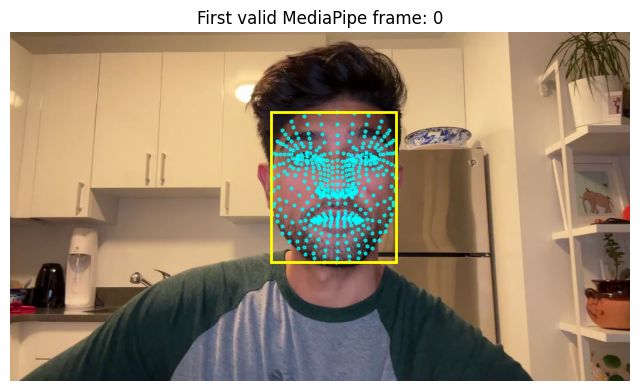

In [6]:
if EXTRACTION_INFO["first_valid_overlay"] is not None:
    show_landmark_overlay(EXTRACTION_INFO["first_valid_overlay"])
else:
    display(Markdown("No valid MediaPipe face was detected in sampled frames."))


## 6. `matrix` pipeline

In [7]:
def build_backend_outputs(
    meta: VideoMeta,
    records: List[SampleRecord],
    backend_name: str,
    normalize_by_bb_size: bool,
) -> Tuple[pd.DataFrame, pd.DataFrame, Dict[int, np.ndarray], Dict[str, float]]:
    if backend_name not in {"matrix", "pnp"}:
        raise ValueError(f"Unsupported backend: {backend_name}")

    start_time = time.perf_counter()
    rows = [get_undetected_facepose(frame_index) for frame_index in range(meta.num_frames)]
    rotations_by_frame: Dict[int, np.ndarray] = {}

    for record in records:
        rotation = record.matrix_rotation if backend_name == "matrix" else record.pnp_rotation
        if record.face_count == 1 and record.bbox_xyxy is not None and rotation is not None:
            pose_pry = rotation_matrix_to_pitch_roll_yaw(rotation)
            rows[record.frame] = make_facepose_row(record.frame, record.bbox_xyxy, pose_pry, face_confidence=1.0)
            rotations_by_frame[record.frame] = rotation

    out_array = np.array(rows, dtype=float)
    out_df = pd.DataFrame(
        out_array,
        columns=["frame", "bb_x1", "bb_y1", "bb_x2", "bb_y2", "face_confidence", "pitch", "roll", "yaw"],
    )
    out_df["time"] = out_df["frame"] / meta.video_fps
    out_df, summary_df = finalize_head_movement_df(out_df, normalize_by_bb_size=normalize_by_bb_size)

    build_ms = (time.perf_counter() - start_time) * 1000.0
    benchmark = {
        "build_ms": build_ms,
        "total_ms": EXTRACTION_INFO["extract_ms"] + build_ms,
        "ms_per_source_frame": (EXTRACTION_INFO["extract_ms"] + build_ms) / meta.num_frames,
        "ms_per_sampled_frame": (EXTRACTION_INFO["extract_ms"] + build_ms) / meta.sampled_frame_count,
    }
    return out_df, summary_df, rotations_by_frame, benchmark


matrix_raw_df, matrix_raw_summary_df, matrix_rotations_by_frame, matrix_benchmark = build_backend_outputs(
    meta=MEDIA_META,
    records=MEDIA_RECORDS,
    backend_name="matrix",
    normalize_by_bb_size=CONFIG["normalize_by_bb_size"],
)

matrix_calibrated_df, matrix_calibrated_summary_df, matrix_calibration_info = build_calibrated_smoothed_variant(
    raw_df=matrix_raw_df,
    rotations_by_frame=matrix_rotations_by_frame,
    neutral_window_seconds=CONFIG["neutral_window_seconds"],
    ema_alpha=CONFIG["ema_alpha"],
    normalize_by_bb_size=CONFIG["normalize_by_bb_size"],
)

assert_framewise_schema(matrix_raw_df)
assert_summary_schema(matrix_raw_summary_df)
assert_framewise_schema(matrix_calibrated_df)
assert_summary_schema(matrix_calibrated_summary_df)

matrix_raw_df.head(12)


,frame,bb_x1,bb_y1,bb_x2,bb_y2,face_confidence,pitch,roll,yaw,time,bb_center_x,bb_center_y,euclidean_angle,euclidean_angle_disp,xy_disp
0,0.0,807.879009,247.683549,1194.777832,712.412696,1.0,-2.217492,0.237324,1.620545,0.000000,1001.328421,480.048122,2.754004,NaN,0.000000
1,1.0,807.205753,241.366239,1194.361496,719.655433,1.0,-2.335005,0.300212,1.713462,0.033333,1000.783625,480.510836,2.908082,0.154078,0.714777
2,2.0,806.878681,239.714170,1194.676094,721.961854,1.0,-2.349496,0.346683,1.806057,0.066667,1000.777388,480.838012,2.979262,0.071180,0.327235
3,3.0,806.815109,239.752954,1195.557518,723.951044,1.0,-2.359234,0.404040,1.804617,0.100000,1001.186314,481.851999,2.992550,0.013288,1.093340
4,4.0,806.817856,239.384966,1196.468697,725.430593,1.0,-2.360153,0.443249,1.879885,0.133333,1001.643276,482.407780,3.043992,0.051442,0.719518
5,5.0,806.795139,238.505180,1196.894760,726.403463,1.0,-2.537920,0.504431,1.958803,0.166667,1001.844950,482.454321,3.238509,0.194517,0.206974
6,6.0,806.451359,238.093096,1197.024651,727.474694,1.0,-2.646276,0.495427,1.999244,0.200000,1001.738005,482.783895,3.346442,0.107934,0.346491
7,7.0,805.509338,237.429877,1197.071342,728.085272,1.0,-2.829815,0.498098,2.022798,0.233333,1001.290340,482.757575,3.506707,0.160265,0.448437
8,8.0,804.820633,236.313906,1197.051430,728.155181,1.0,-3.050371,0.504075,2.039180,0.266667,1000.936031,482.234544,3.696122,0.189415,0.631741
9,9.0,804.608688,234.951548,1196.870499,727.726264,1.0,-3.362176,0.474997,2.078840,0.300000,1000.739594,481.338906,3.973934,0.277812,0.916927


In [8]:
matrix_raw_summary_df


,xy_disp_mean,pitch_mean,yaw_mean,roll_mean,euclidean_angle_disp_mean,xy_disp_std,pitch_std,yaw_std,roll_std,euclidean_angle_disp_std
0,3.159864,2.09601,-1.034108,-3.826325,0.596444,2.610221,6.051301,4.581241,2.252905,0.701245


## 7. `pnp` pipeline

In [9]:
pnp_raw_df, pnp_raw_summary_df, pnp_rotations_by_frame, pnp_benchmark = build_backend_outputs(
    meta=MEDIA_META,
    records=MEDIA_RECORDS,
    backend_name="pnp",
    normalize_by_bb_size=CONFIG["normalize_by_bb_size"],
)

pnp_calibrated_df, pnp_calibrated_summary_df, pnp_calibration_info = build_calibrated_smoothed_variant(
    raw_df=pnp_raw_df,
    rotations_by_frame=pnp_rotations_by_frame,
    neutral_window_seconds=CONFIG["neutral_window_seconds"],
    ema_alpha=CONFIG["ema_alpha"],
    normalize_by_bb_size=CONFIG["normalize_by_bb_size"],
)

assert_framewise_schema(pnp_raw_df)
assert_summary_schema(pnp_raw_summary_df)
assert_framewise_schema(pnp_calibrated_df)
assert_summary_schema(pnp_calibrated_summary_df)

pnp_raw_df.head(12)


,frame,bb_x1,bb_y1,bb_x2,bb_y2,face_confidence,pitch,roll,yaw,time,bb_center_x,bb_center_y,euclidean_angle,euclidean_angle_disp,xy_disp
0,0.0,807.879009,247.683549,1194.777832,712.412696,1.0,-178.922481,-0.141271,6.252311,0.000000,1001.328421,480.048122,178.931790,NaN,0.000000
1,1.0,807.205753,241.366239,1194.361496,719.655433,1.0,-179.067939,-0.124384,7.693402,0.033333,1000.783625,480.510836,179.078384,0.146595,0.714777
2,2.0,806.878681,239.714170,1194.676094,721.961854,1.0,-179.184485,-0.129275,8.487797,0.066667,1000.777388,480.838012,179.196288,0.117904,0.327235
3,3.0,806.815109,239.752954,1195.557518,723.951044,1.0,-179.264468,-0.098209,8.655835,0.100000,1001.186314,481.851999,179.273977,0.077688,1.093340
4,4.0,806.817856,239.384966,1196.468697,725.430593,1.0,-179.235926,-0.099983,9.456773,0.133333,1001.643276,482.407780,179.246768,0.027208,0.719518
5,5.0,806.795139,238.505180,1196.894760,726.403463,1.0,-179.333614,-0.048691,9.478677,0.166667,1001.844950,482.454321,179.339915,0.093147,0.206974
6,6.0,806.451359,238.093096,1197.024651,727.474694,1.0,-179.386431,-0.064478,9.514749,0.200000,1001.738005,482.783895,179.393893,0.053977,0.346491
7,7.0,805.509338,237.429877,1197.071342,728.085272,1.0,-179.405901,-0.071383,9.666780,0.233333,1001.290340,482.757575,179.414029,0.020136,0.448437
8,8.0,804.820633,236.313906,1197.051430,728.155181,1.0,-179.420883,-0.069268,9.756922,0.266667,1000.936031,482.234544,179.428871,0.014842,0.631741
9,9.0,804.608688,234.951548,1196.870499,727.726264,1.0,-179.481082,-0.076682,10.018100,0.300000,1000.739594,481.338906,179.489759,0.060888,0.916927


In [10]:
pnp_raw_summary_df


,xy_disp_mean,pitch_mean,yaw_mean,roll_mean,euclidean_angle_disp_mean,xy_disp_std,pitch_std,yaw_std,roll_std,euclidean_angle_disp_std
0,3.159864,-94.955061,-2.50609,-2.108467,0.857845,2.610221,148.444984,19.952846,19.447796,3.390766


## 8. `owf.head_movement()` reference run

In [11]:
reference_start = time.perf_counter()
owf_head_movement_df, owf_summary_df = owf.head_movement(
    video_path=str(CONFIG["video_path"]),
    frames_per_second=CONFIG["frames_per_second"],
    normalize_by_bb_size=CONFIG["normalize_by_bb_size"],
    bbox_list=CONFIG["bbox_list"],
    padding_percent=CONFIG["padding_percent"],
)
owf_total_ms = (time.perf_counter() - reference_start) * 1000.0

assert_framewise_schema(owf_head_movement_df)
assert_summary_schema(owf_summary_df)

owf_benchmark = {
    "total_ms": owf_total_ms,
    "ms_per_source_frame": owf_total_ms / len(owf_head_movement_df),
    "ms_per_sampled_frame": owf_total_ms / len(range(0, len(owf_head_movement_df), MEDIA_META.skip_interval)),
}

owf_head_movement_df.head(12)


INFO:root:Loading Face model: retinaface
INFO:root:Loading Facial Landmark model: mobilefacenet
INFO:root:Loading facepose model: img2pose
INFO:root:Loading AU model: xgb
INFO:root:Loading emotion model: resmasknet
INFO:root:Loading Identity model: facenet
INFO:root:detecting poses...
INFO:root:img2pose: RESCALING WARNING: img2pose has a min img size of 400 and a max img size of 1400 but checked value is torch.Size([1080, 1920]).
INFO:root:detecting poses...
INFO:root:img2pose: RESCALING WARNING: img2pose has a min img size of 400 and a max img size of 1400 but checked value is torch.Size([1080, 1920]).
INFO:root:detecting poses...
INFO:root:img2pose: RESCALING WARNING: img2pose has a min img size of 400 and a max img size of 1400 but checked value is torch.Size([1080, 1920]).
INFO:root:detecting poses...
INFO:root:img2pose: RESCALING WARNING: img2pose has a min img size of 400 and a max img size of 1400 but checked value is torch.Size([1080, 1920]).
INFO:root:detecting poses...
INFO:r

,frame,bb_x1,bb_y1,bb_x2,bb_y2,face_confidence,pitch,roll,yaw,time,bb_center_x,bb_center_y,euclidean_angle,euclidean_angle_disp,xy_disp
0,0.0,783.0,172.0,1215.0,712.0,0.974904,3.937711,-0.415654,-2.253198,0.000000,999.0,442.0,4.562622,NaN,0.000000
1,1.0,783.0,172.0,1215.0,712.0,0.975215,4.039510,-0.379902,-2.209774,0.033333,999.0,442.0,4.626246,0.063624,0.000000
2,2.0,783.0,175.0,1215.0,712.0,0.976003,3.743224,-0.220821,-2.643445,0.066667,999.0,443.5,4.591722,0.034524,1.500000
3,3.0,785.0,180.0,1215.0,715.0,0.977276,3.255390,-0.480572,-2.542509,0.100000,1000.0,447.5,4.166587,0.425135,4.123106
4,4.0,788.0,178.0,1217.0,715.0,0.977967,2.753902,-0.612429,-2.362055,0.133333,1002.5,446.5,3.688723,0.477864,2.692582
5,5.0,785.0,178.0,1217.0,717.0,0.977067,3.251359,-0.486615,-2.306702,0.166667,1001.0,447.5,4.023826,0.335103,1.802776
6,6.0,785.0,180.0,1217.0,717.0,0.977178,3.310911,-0.463555,-2.173434,0.200000,1001.0,448.5,3.994703,0.029123,1.000000
7,7.0,783.0,178.0,1215.0,715.0,0.978057,3.083471,-0.511859,-2.201727,0.233333,999.0,446.5,3.831028,0.163674,2.828427
8,8.0,783.0,175.0,1215.0,715.0,0.977693,3.236027,-0.469041,-2.224964,0.266667,999.0,445.0,3.962307,0.131279,1.500000
9,9.0,777.0,178.0,1212.0,717.0,0.976975,3.856051,-0.408458,-2.449379,0.300000,994.5,447.5,4.593518,0.631211,5.147815


In [12]:
owf_summary_df


,xy_disp_mean,pitch_mean,yaw_mean,roll_mean,euclidean_angle_disp_mean,xy_disp_std,pitch_std,yaw_std,roll_std,euclidean_angle_disp_std
0,5.610718,-0.897279,-0.801461,3.813777,0.746908,4.907547,4.751389,4.336846,2.139319,0.875035


## 9. Side-by-side comparison tables and plots

In [13]:
def make_coverage_table(reference_df: pd.DataFrame, candidate_dfs: Dict[str, pd.DataFrame]) -> pd.DataFrame:
    rows = []
    reference_valid = int(reference_df["pitch"].notna().sum())
    for name, candidate_df in candidate_dfs.items():
        candidate_valid = int(candidate_df["pitch"].notna().sum())
        overlap = int(reference_df[["frame", "pitch"]].merge(
            candidate_df[["frame", "pitch"]],
            on="frame",
            suffixes=("_ref", "_cand"),
        ).dropna().shape[0])
        rows.append({
            "backend": name,
            "source_frames": len(candidate_df),
            "reference_valid_pose_frames": reference_valid,
            "candidate_valid_pose_frames": candidate_valid,
            "candidate_missing_pose_frames": len(candidate_df) - candidate_valid,
            "overlap_valid_pose_frames": overlap,
        })
    return pd.DataFrame(rows)


def compare_framewise(reference_df: pd.DataFrame, candidate_df: pd.DataFrame, label: str) -> pd.DataFrame:
    ref_cols = ["frame", "bb_center_x", "bb_center_y", "pitch", "roll", "yaw"]
    cand_cols = ["frame", "bb_center_x", "bb_center_y", "pitch", "roll", "yaw"]
    merged = reference_df[ref_cols].merge(candidate_df[cand_cols], on="frame", suffixes=("_ref", "_cand"))
    merged = merged.dropna(subset=["pitch_ref", "pitch_cand", "roll_ref", "roll_cand", "yaw_ref", "yaw_cand"])
    rows = []
    for metric in ["pitch", "roll", "yaw"]:
        signed_delta = merged[f"{metric}_cand"] - merged[f"{metric}_ref"]
        rows.append({
            "backend": label,
            "metric": metric,
            "valid_overlap": len(merged),
            "signed_mean_diff": signed_delta.mean(),
            "signed_median_diff": signed_delta.median(),
            "mean_absolute_diff": signed_delta.abs().mean(),
            "max_absolute_diff": signed_delta.abs().max(),
        })
    bbox_l2 = np.sqrt((merged["bb_center_x_cand"] - merged["bb_center_x_ref"]) ** 2 + (merged["bb_center_y_cand"] - merged["bb_center_y_ref"]) ** 2)
    rows.append({
        "backend": label,
        "metric": "bb_center_l2",
        "valid_overlap": len(merged),
        "signed_mean_diff": np.nan,
        "signed_median_diff": np.nan,
        "mean_absolute_diff": bbox_l2.mean(),
        "max_absolute_diff": bbox_l2.max(),
    })
    return pd.DataFrame(rows)


def compare_summary(reference_summary_df: pd.DataFrame, candidate_summary_df: pd.DataFrame, label: str) -> pd.DataFrame:
    delta = candidate_summary_df.iloc[0] - reference_summary_df.iloc[0]
    out_df = pd.DataFrame([delta], index=[label])
    out_df.index.name = "backend"
    return out_df.reset_index()


candidate_raw_dfs = {
    "matrix_raw": matrix_raw_df,
    "pnp_raw": pnp_raw_df,
}

coverage_table = make_coverage_table(owf_head_movement_df, candidate_raw_dfs)
framewise_comparison_df = pd.concat([
    compare_framewise(owf_head_movement_df, matrix_raw_df, "matrix_raw"),
    compare_framewise(owf_head_movement_df, pnp_raw_df, "pnp_raw"),
], ignore_index=True)
summary_delta_df = pd.concat([
    compare_summary(owf_summary_df, matrix_raw_summary_df, "matrix_raw"),
    compare_summary(owf_summary_df, pnp_raw_summary_df, "pnp_raw"),
], ignore_index=True)

coverage_table


,backend,source_frames,reference_valid_pose_frames,candidate_valid_pose_frames,candidate_missing_pose_frames,overlap_valid_pose_frames
0,matrix_raw,644,644,644,0,644
1,pnp_raw,644,644,644,0,644


In [14]:
framewise_comparison_df


,backend,metric,valid_overlap,signed_mean_diff,signed_median_diff,mean_absolute_diff,max_absolute_diff
0,matrix_raw,pitch,644,2.993289,1.617142,8.315505,35.270294
1,matrix_raw,roll,644,-7.640102,-8.111252,7.838324,18.174356
2,matrix_raw,yaw,644,-0.232648,-0.720058,6.499549,29.008957
3,matrix_raw,bb_center_l2,644,NaN,NaN,45.152130,70.394764
4,pnp_raw,pitch,644,-94.057782,-171.821441,173.712500,186.011797
5,pnp_raw,roll,644,-5.922243,-8.451625,10.113378,166.783918
6,pnp_raw,yaw,644,-1.704630,3.015638,20.431610,55.247710
7,pnp_raw,bb_center_l2,644,NaN,NaN,45.152130,70.394764


In [15]:
summary_delta_df


,backend,xy_disp_mean,pitch_mean,yaw_mean,roll_mean,euclidean_angle_disp_mean,xy_disp_std,pitch_std,yaw_std,roll_std,euclidean_angle_disp_std
0,matrix_raw,-2.450855,2.993289,-0.232648,-7.640102,-0.150464,-2.297327,1.299913,0.244395,0.113586,-0.173790
1,pnp_raw,-2.450855,-94.057782,-1.704630,-5.922243,0.110937,-2.297327,143.693596,15.615999,17.308477,2.515731


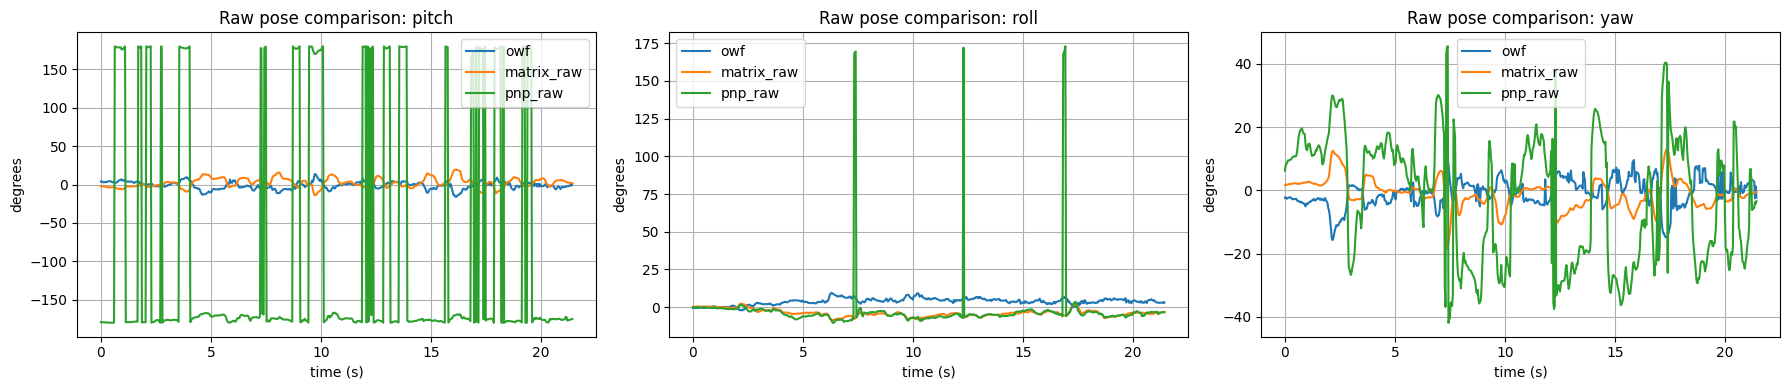

In [16]:
def plot_pose_trajectories(series_map: Dict[str, pd.DataFrame], title_prefix: str) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True)
    metrics = ["pitch", "roll", "yaw"]
    for ax, metric in zip(axes, metrics):
        for label, df in series_map.items():
            sampled = df[["time", metric]].dropna()
            ax.plot(sampled["time"], sampled[metric], label=label, linewidth=1.5)
        ax.set_title(f"{title_prefix}: {metric}")
        ax.set_xlabel("time (s)")
        ax.set_ylabel("degrees")
        ax.legend()
    plt.tight_layout()
    plt.show()


def plot_raw_vs_calibrated(raw_df: pd.DataFrame, calibrated_df: pd.DataFrame, backend_name: str) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True)
    for ax, metric in zip(axes, ["pitch", "roll", "yaw"]):
        raw_sampled = raw_df[["time", metric]].dropna()
        calibrated_sampled = calibrated_df[["time", metric]].dropna()
        ax.plot(raw_sampled["time"], raw_sampled[metric], label="raw", linewidth=1.2)
        ax.plot(calibrated_sampled["time"], calibrated_sampled[metric], label="calibrated_smoothed", linewidth=1.2)
        ax.set_title(f"{backend_name}: {metric}")
        ax.set_xlabel("time (s)")
        ax.set_ylabel("degrees")
        ax.legend()
    plt.tight_layout()
    plt.show()


plot_pose_trajectories(
    {
        "owf": owf_head_movement_df,
        "matrix_raw": matrix_raw_df,
        "pnp_raw": pnp_raw_df,
    },
    title_prefix="Raw pose comparison",
)


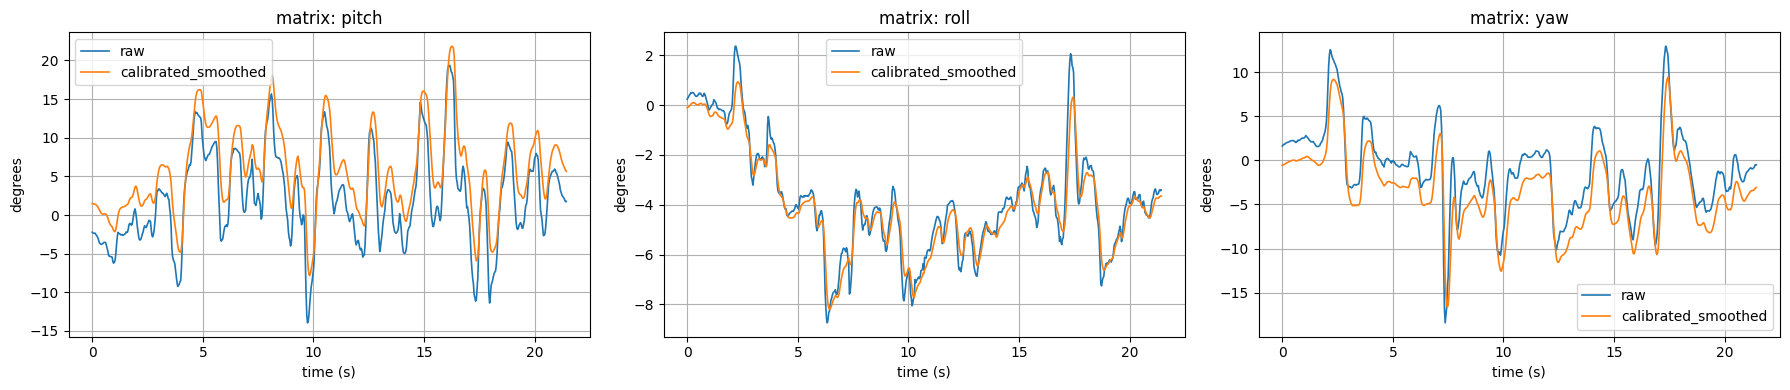

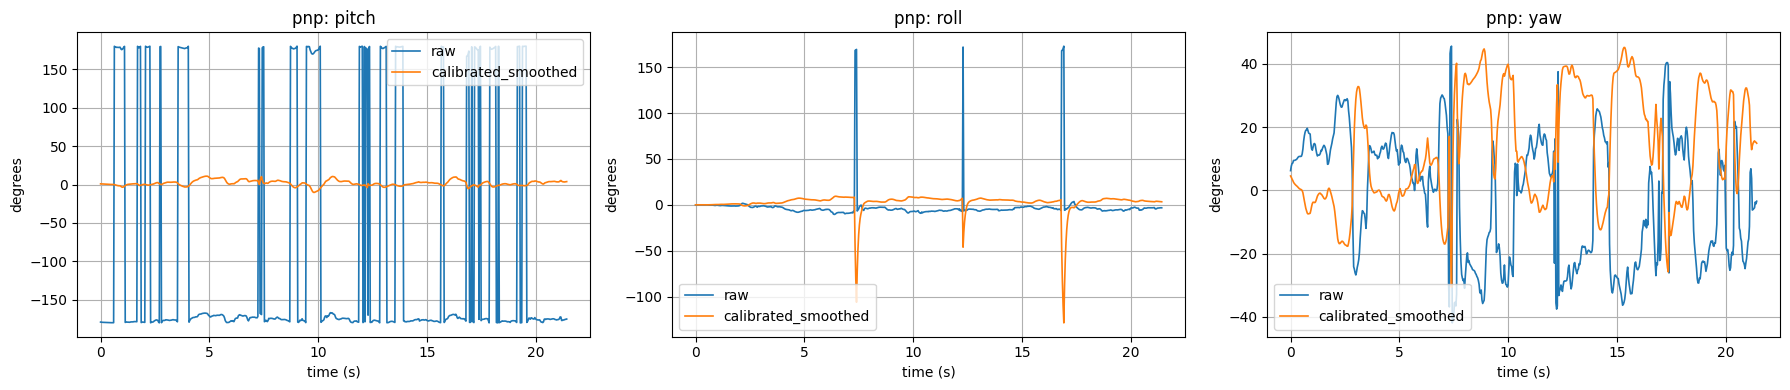

In [17]:
plot_raw_vs_calibrated(matrix_raw_df, matrix_calibrated_df, "matrix")
plot_raw_vs_calibrated(pnp_raw_df, pnp_calibrated_df, "pnp")


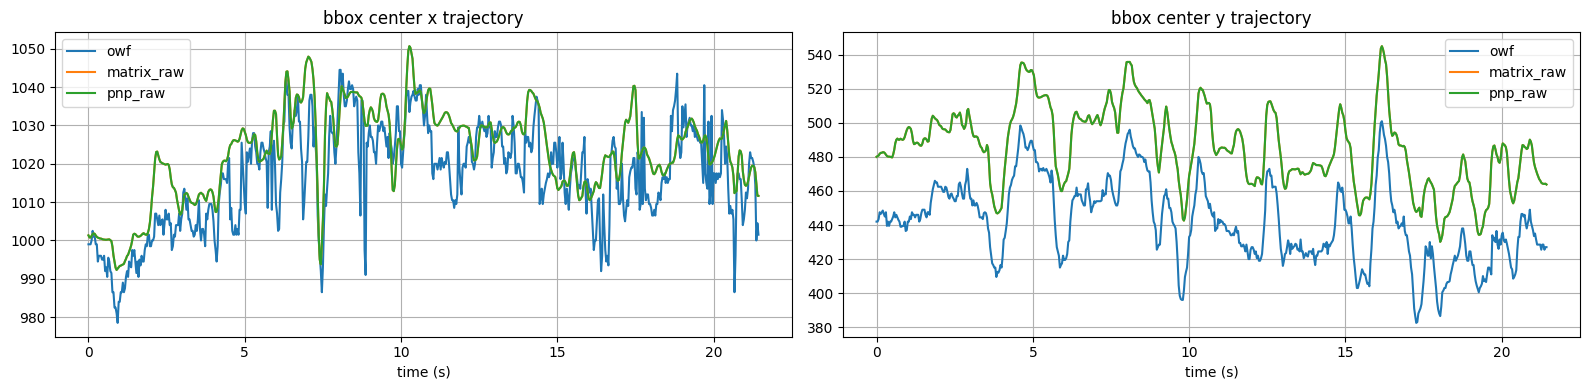

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharex=True)
for label, df in {"owf": owf_head_movement_df, "matrix_raw": matrix_raw_df, "pnp_raw": pnp_raw_df}.items():
    sampled = df[["time", "bb_center_x", "bb_center_y"]].dropna()
    axes[0].plot(sampled["time"], sampled["bb_center_x"], label=label)
    axes[1].plot(sampled["time"], sampled["bb_center_y"], label=label)
axes[0].set_title("bbox center x trajectory")
axes[1].set_title("bbox center y trajectory")
for ax in axes:
    ax.set_xlabel("time (s)")
    ax.legend()
plt.tight_layout()
plt.show()


## 10. Runtime benchmark table

In [19]:
benchmark_df = pd.DataFrame([
    {
        "pipeline": "owf.head_movement",
        "total_ms": owf_benchmark["total_ms"],
        "ms_per_source_frame": owf_benchmark["ms_per_source_frame"],
        "ms_per_sampled_frame": owf_benchmark["ms_per_sampled_frame"],
    },
    {
        "pipeline": "mediapipe.matrix_raw",
        "total_ms": matrix_benchmark["total_ms"],
        "ms_per_source_frame": matrix_benchmark["ms_per_source_frame"],
        "ms_per_sampled_frame": matrix_benchmark["ms_per_sampled_frame"],
    },
    {
        "pipeline": "mediapipe.pnp_raw",
        "total_ms": pnp_benchmark["total_ms"],
        "ms_per_source_frame": pnp_benchmark["ms_per_source_frame"],
        "ms_per_sampled_frame": pnp_benchmark["ms_per_sampled_frame"],
    },
    {
        "pipeline": "mediapipe.shared_extract_only",
        "total_ms": EXTRACTION_INFO["extract_ms"],
        "ms_per_source_frame": EXTRACTION_INFO["extract_ms"] / MEDIA_META.num_frames,
        "ms_per_sampled_frame": EXTRACTION_INFO["extract_ms"] / MEDIA_META.sampled_frame_count,
    },
]).sort_values("total_ms")

benchmark_df


,pipeline,total_ms,ms_per_source_frame,ms_per_sampled_frame
3,mediapipe.shared_extract_only,6851.583584,10.639105,10.639105
1,mediapipe.matrix_raw,6884.071042,10.689551,10.689551
2,mediapipe.pnp_raw,6887.981834,10.695624,10.695624
0,owf.head_movement,304321.123958,472.548329,472.548329


## 11. Conclusions / observed deltas

In [20]:
def summarize_observations() -> None:
    best_runtime_row = benchmark_df.sort_values("total_ms").iloc[0]
    matrix_pitch_row = framewise_comparison_df[(framewise_comparison_df["backend"] == "matrix_raw") & (framewise_comparison_df["metric"] == "pitch")].iloc[0]
    pnp_pitch_row = framewise_comparison_df[(framewise_comparison_df["backend"] == "pnp_raw") & (framewise_comparison_df["metric"] == "pitch")].iloc[0]

    lines = [
        "### Observations",
        f"- Fastest measured path in this notebook: `{best_runtime_row['pipeline']}` at `{best_runtime_row['total_ms']:.2f}` ms total.",
        f"- MediaPipe shared extraction cost: `{EXTRACTION_INFO['extract_ms']:.2f}` ms across `{MEDIA_META.sampled_frame_count}` sampled frames.",
        f"- `matrix_raw` pitch mean absolute difference vs `owf`: `{matrix_pitch_row['mean_absolute_diff']:.3f}` degrees.",
        f"- `pnp_raw` pitch mean absolute difference vs `owf`: `{pnp_pitch_row['mean_absolute_diff']:.3f}` degrees.",
        f"- Matrix baseline used `{len(matrix_calibration_info['baseline_frames'])}` sampled frames from the first `{CONFIG['neutral_window_seconds']}` second(s).",
        f"- PnP baseline used `{len(pnp_calibration_info['baseline_frames'])}` sampled frames from the first `{CONFIG['neutral_window_seconds']}` second(s).",
    ]
    display(Markdown("\n".join(lines)))


summarize_observations()


### Observations
- Fastest measured path in this notebook: `mediapipe.shared_extract_only` at `6851.58` ms total.
- MediaPipe shared extraction cost: `6851.58` ms across `644` sampled frames.
- `matrix_raw` pitch mean absolute difference vs `owf`: `8.316` degrees.
- `pnp_raw` pitch mean absolute difference vs `owf`: `173.713` degrees.
- Matrix baseline used `31` sampled frames from the first `1.0` second(s).
- PnP baseline used `31` sampled frames from the first `1.0` second(s).